# Demo on Casual Inference
In this example we demo **Email Campaign**(*T*) where **Historical Spend** (*X*) acts as a confounder affecting both campaign targeted status (*T*) and **Current Spending** (*Y*)

In [1]:
import numpy as np
import pandas as pd
import dowhy
from dowhy import CausalModel

/Users/jasonlau/Documents/Software/AI_Experiments/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Generate Synthetic Marketing Data

In [2]:
np.random.seed(42)
n_samples = 2000

In [3]:
# Confounder: Historical Spend
historical_spend = np.random.gamma(shape=5, scale=20, size=n_samples)

In [4]:
# Treatment: Email Campaign (High spenders are more likely to get targeted)
propensity = 1 / (1 + np.exp(-(-2.0 + 0.015 * historical_spend)))
T = np.random.binomial(1, propensity)

In [5]:
true_effect = 20.0

In [6]:
# Outcome: Revenue (True incremental effect of campaign = +$20.00)
noise = np.random.normal(0, 10, size=n_samples)
Y = 0.4 * historical_spend + true_effect * T + noise

In [7]:
df = pd.DataFrame({
    'historical_spend': historical_spend,
    'T': T,
    'Y': Y
})

## Model the Casual Graph (DAG)

In [8]:
# Express relationships:
# - historical_spend -> T  (Confounder driving treatment)
# - historical_spend -> Y  (Confounder driving outcome)
# - T -> Y                 (Causal link we want to estimate)

causal_graph = """
digraph {
    historical_spend -> T;
    historical_spend -> Y;
    T -> Y;
}
"""

In [9]:
model = CausalModel(
    data=df,
    treatment='T',
    outcome='Y',
    graph=causal_graph
)

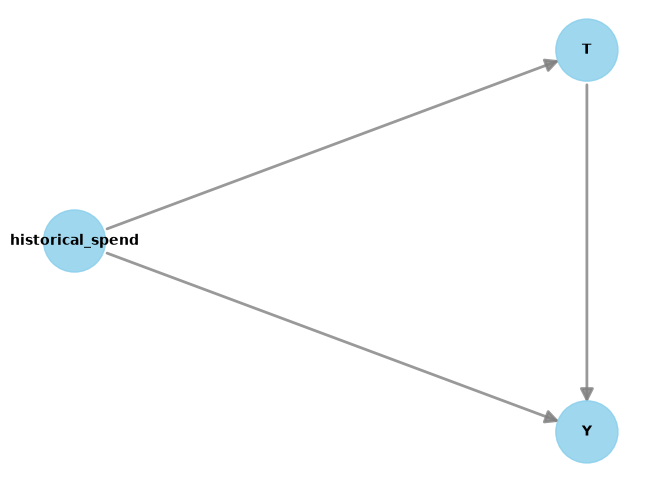

In [10]:
model.view_model()

## Identify the Casual Effect

In [11]:
# DoWhy checks the DAG and determines the valid adjustment sets (e.g., Backdoor criterion)
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)

In [12]:
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
 d                         
────(E[Y|historical_spend])
d[T]                       
Estimand assumption 1, Unconfoundedness: If U→{T} and U→Y then P(Y|T,historical_spend,U) = P(Y|T,historical_spend)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
 d                         
────(E[Y|historical_spend])
d[T]                       
Estimand assumption 1, Unconfoundedness: If U→{T} and U→Y then P(Y|T,historical_spend,U) = P(Y|T,historical_spend)



## Estimate the Effect

In [13]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_weighting"
)

In [14]:
print("\n--- Causal Estimate ---")
print(f"Estimated ATE: ${estimate.value:.2f}")
print(f"True ATE     : ${true_effect:.2f}")


--- Causal Estimate ---
Estimated ATE: $20.95
True ATE     : $20.00


## Refute the Estimate (Stress Testing Assumptions)

In [15]:
# Test 1: Add a Random Common Cause
# Adds a random variable to data; the estimated ATE should NOT change significantly.
refute_random = model.refute_estimate(
    identified_estimand, 
    estimate, 
    method_name="random_common_cause"
)
print("\n--- Refutation 1: Random Common Cause ---")
print(f"New Effect Estimate: ${refute_random.new_effect:.2f}")


--- Refutation 1: Random Common Cause ---
New Effect Estimate: $20.95


### Note: DoWhy bug affecting the placebo test below

`model.estimate_effect(...)` mutates `df` in place, adding a `propensity_score` column (and related weight columns) computed from the **real** treatment `T` (`model._data is df` → `True`). `PropensityScoreEstimator.fit()` / `estimate_effect()` only (re)compute propensity scores `if self.propensity_score_column not in data`, so when `placebo_treatment_refuter` later builds its permuted-treatment dataset from this same (now-polluted) `df`, it silently reuses the stale propensity scores fit on the real `T` instead of refitting them on the permuted placebo treatment.

The result: IPW weights are computed from "who was really targeted" but applied to a treatment label that's been randomly shuffled, so they no longer cancel out — producing a large, spurious placebo effect (~-13 to -15, varying by RNG seed) instead of ~0. This is a DoWhy artifact, not a flaw in the causal identification above.

Note that simply rebuilding the `CausalModel` on a fresh copy of the raw columns does **not** fix it — calling `estimate_effect()` on that fresh copy re-pollutes it the same way. The fix has to strip the derived columns from `model._data` *after* the estimate is computed but *before* `refute_estimate` runs.</cell id="356467fc">


In [16]:
# Test 2: Placebo Treatment
# Replaces real treatment T with a random dummy variable; the estimated ATE should drop to ~0.
#
# Workaround for the DoWhy bug noted above: `estimate_effect` already wrote a
# `propensity_score` column (and derived weight columns) into `model._data`
# using the REAL treatment. Strip those before refuting so the refuter is
# forced to refit propensity scores on the placebo (permuted) treatment
# instead of silently reusing the stale ones.
derived_cols = [c for c in model._data.columns if c not in ('historical_spend', 'T', 'Y')]
model._data.drop(columns=derived_cols, inplace=True)

refute_placebo = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute"
)
print("\n--- Refutation 2: Placebo Treatment ---")
print(f"New Effect Estimate: ${refute_placebo.new_effect:.2f} (Should be close to 0)")


--- Refutation 2: Placebo Treatment ---
New Effect Estimate: $-0.01 (Should be close to 0)
